# 01 — Data Pipeline

Demonstrates fetching historical prices, Polymarket markets, and sentiment data using the `research` package.

**Prerequisites:**
```bash
conda activate cramer-research
cd ../research && pip install -e . && cd ../notebooks
```

In [1]:
import os
import sys

# Ensure research package is importable
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import matplotlib.pyplot as plt

from research.data.prices import fetch_historical_prices
from research.data.polymarket import fetch_polymarket_markets
from research.data.sentiment import fetch_fear_greed, fetch_social_sentiment

## 1. Historical Prices

Fetch daily closes with automatic fallback chain:
1. Financial Datasets API (primary)
2. Binance (crypto fallback)
3. Yahoo Finance (broad fallback)

In [2]:
TICKER = "BTC"
DAYS = 120

prices = fetch_historical_prices(TICKER, days=DAYS)
print(f"Source: {prices.attrs.get('source', 'unknown')}")
print(f"Fetched {len(prices)} days")
prices.tail(10)

Source: binance
Fetched 120 days


,date,close
110,2026-04-18,75691.76
111,2026-04-19,73801.79
112,2026-04-20,75840.97
113,2026-04-21,76336.15
114,2026-04-22,78178.23
115,2026-04-23,78257.48
116,2026-04-24,77437.13
117,2026-04-25,77625.00
118,2026-04-26,78657.55
119,2026-04-27,77625.63


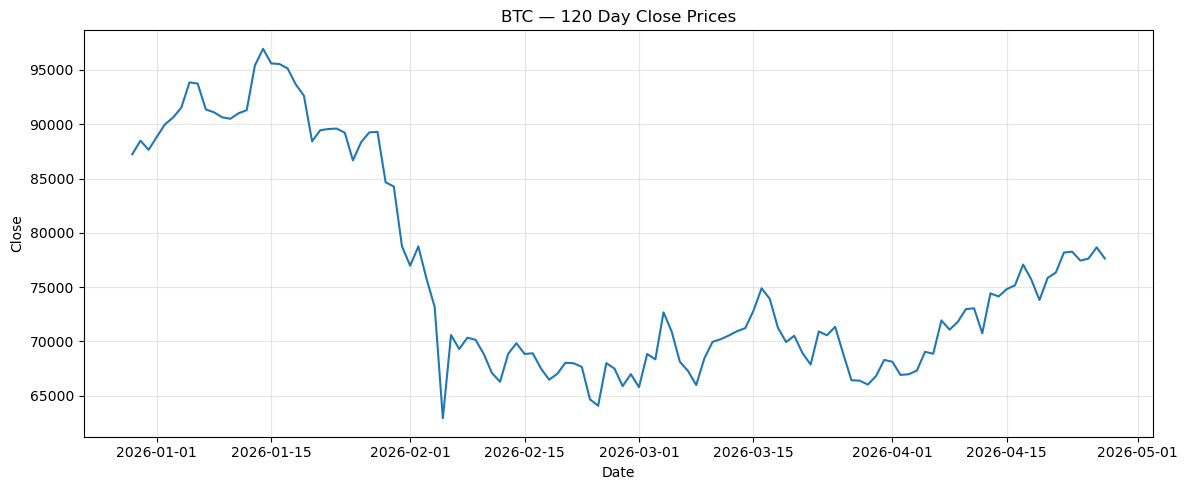

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(prices['date'], prices['close'], linewidth=1.5)
ax.set_title(f"{TICKER} — {DAYS} Day Close Prices")
ax.set_xlabel("Date")
ax.set_ylabel("Close")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Polymarket Markets

Search Polymarket prediction markets for a given query.

- Tag-slug inference (keyword param is non-functional on Gamma API)
- Client-side text filtering
- 5-minute TTL cache with LRU eviction

In [4]:
QUERY = "bitcoin"

markets = fetch_polymarket_markets(QUERY, limit=10)
print(f"Found {len(markets)} markets")
markets.head()

Found 0 markets


,market_id,question,probability,volume_24h,age_days,end_date,event_title


No markets found


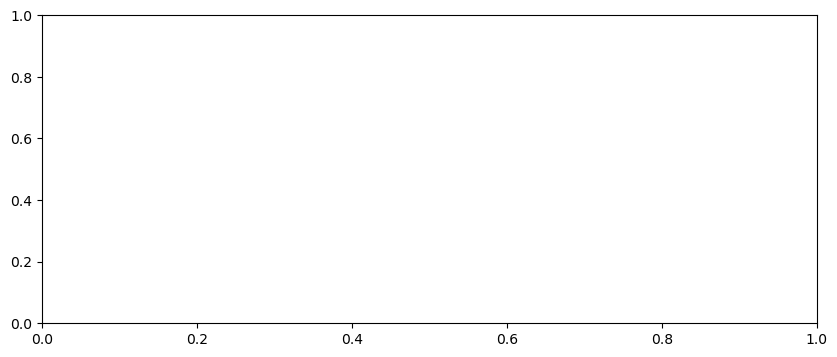

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
if not markets.empty:
    ax.barh(markets['question'].str[:60], markets['probability'] * 100)
    ax.set_xlabel("YES Probability (%)")
    ax.set_title(f"Polymarket Markets — {QUERY}")
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
else:
    print("No markets found")

## 3. Fear & Greed Index

Fetch crypto fear & greed from alternative.me

In [6]:
fng = fetch_fear_greed(limit=30)
print(f"Fetched {len(fng)} days of Fear & Greed")
fng.tail(10)

Fetched 30 days of Fear & Greed


,date,value,classification
20,2026-04-18,26,Fear
21,2026-04-19,27,Fear
22,2026-04-20,29,Fear
23,2026-04-21,33,Fear
24,2026-04-22,32,Fear
25,2026-04-23,46,Fear
26,2026-04-24,39,Fear
27,2026-04-25,31,Fear
28,2026-04-26,33,Fear
29,2026-04-27,47,Neutral


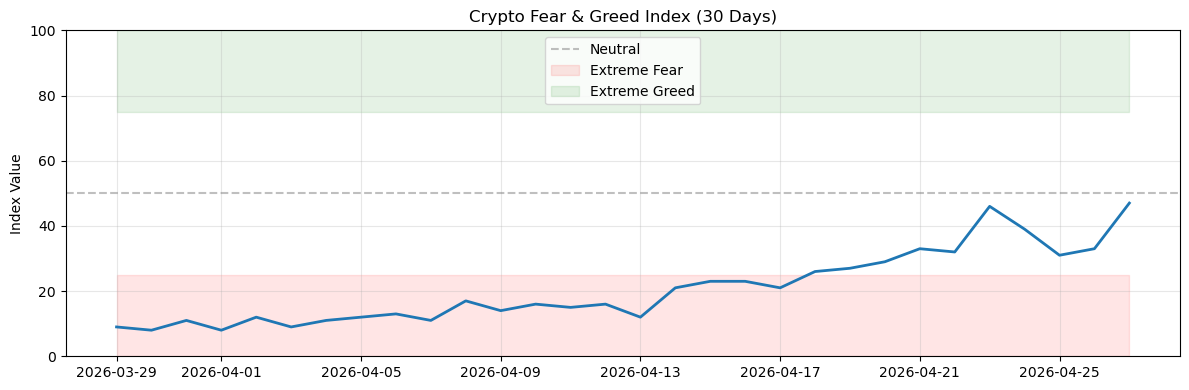

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
if not fng.empty:
    ax.plot(fng['date'], fng['value'], linewidth=2)
    ax.axhline(50, color='gray', linestyle='--', alpha=0.5, label='Neutral')
    ax.fill_between(fng['date'], 0, 25, alpha=0.1, color='red', label='Extreme Fear')
    ax.fill_between(fng['date'], 75, 100, alpha=0.1, color='green', label='Extreme Greed')
    ax.set_ylim(0, 100)
    ax.set_title("Crypto Fear & Greed Index (30 Days)")
    ax.set_ylabel("Index Value")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No Fear & Greed data available")

## 4. Returns & Regime Preview

Quick preview of returns and regime classification before the full Markov notebook.

In [8]:
from research.models.markov import classify_regime_series

prices['returns'] = prices['close'].pct_change()
returns = prices['returns'].dropna().values

regimes = classify_regime_series(returns)
print(f"Regime counts: bull={regimes.count('bull')}, bear={regimes.count('bear')}, sideways={regimes.count('sideways')}")

Regime counts: bull=40, bear=44, sideways=35


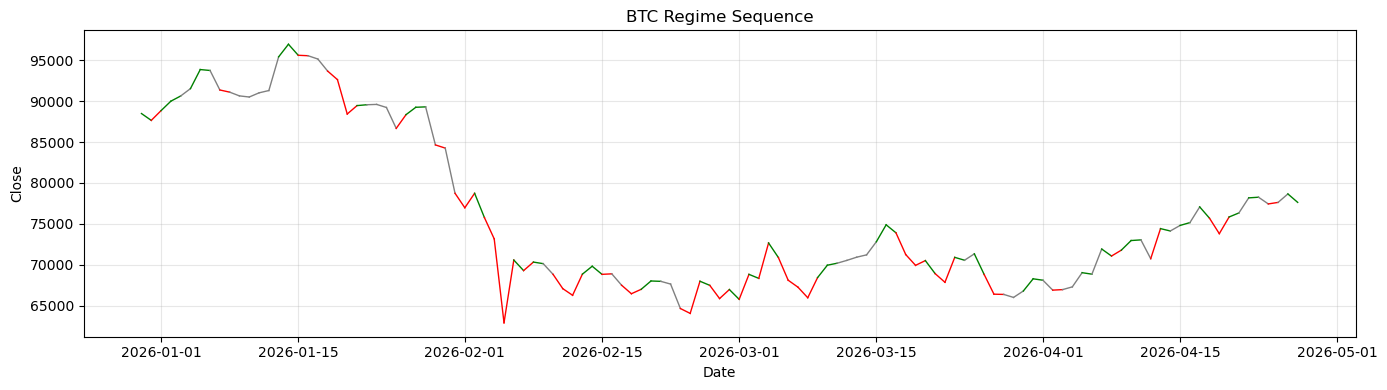

In [9]:
from research.viz.distributions import plot_regime_sequence

fig = plot_regime_sequence(prices.iloc[1:], regimes, title=f"{TICKER} Regime Sequence")
plt.tight_layout()
plt.show()